<a href="https://colab.research.google.com/github/klaswijk/wasp-nlp/blob/main/a4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

In [ ]:
torch.cuda.get_device_name(0)

'NVIDIA A100-SXM4-80GB'

# WASP NLP Assignment 4: Retrieval-augmented generation
Building a RAG pipeline using LangChain

In [ ]:
%%capture
!pip install langchain langchain-community langchain-huggingface langchain-core sentence_transformers langchain-chroma seaborn
!wget https://raw.githubusercontent.com/pubmedqa/pubmedqa/refs/heads/master/data/ori_pqal.json

In [ ]:
import pandas as pd
import tqdm
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from langchain_huggingface import HuggingFacePipeline, HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma

/home/x_klawi/.conda/envs/pytorch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## ⚙  Task 1.1. Downloading and inspecting the question answering dataset

In [ ]:
tmp_data = pd.read_json("ori_pqal.json").T
# some labels have been defined as "maybe", only keep the yes/no answers
tmp_data = tmp_data[tmp_data.final_decision.isin(["yes", "no"])]

documents = pd.DataFrame({"abstract": tmp_data.apply(lambda row: (" ").join(row.CONTEXTS+[row.LONG_ANSWER]), axis=1),
             "year": tmp_data.YEAR})
questions = pd.DataFrame({"question": tmp_data.QUESTION,
             "year": tmp_data.YEAR,
             "gold_label": tmp_data.final_decision,
             "gold_context": tmp_data.LONG_ANSWER,
             "gold_document_id": documents.index})

In [ ]:
# Sanity check
sample_question = questions.iloc[0].question
sample_answer = documents.iloc[0].abstract
print("Q", sample_question)
print("A", sample_answer)

Q Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?
A Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants. The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madagascariensis. A single areole within a window stage leaf (PCD is occurring) was divided into three areas based on the progression of PCD; cells that will not undergo PCD (NPCD), cells in early stages of PCD (EPCD), and cells in late stages of PC

## ⚙ Task 2.1. Select a language model

In [ ]:
from transformers import GenerationConfig

model = HuggingFacePipeline.from_model_id(
    model_id="Qwen/Qwen3-8B",
    task="text-generation",
    pipeline_kwargs={
        "max_new_tokens": 2,
        "do_sample": False,  # Ensure consistent output
        "return_full_text": False, # Crucial to only return generated text
    }
)

Loading weights: 100%|███████████████████████████████████████████████████| 399/399 [00:00<00:00, 2166.49it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [ ]:
model.invoke(sample_question)

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Both `max_new_tokens` (=2) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


' - Science'

## 🎓 Task 3.1. Embedding model

In [ ]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-mpnet-base-v2",
    #encode_kwargs={"normalize_embeddings": True},
)

Loading weights: 100%|███████████████████████████████████████████████████| 199/199 [00:00<00:00, 9431.90it/s]


In [ ]:
# Sanity check
emb = embeddings.embed_query(sample_question)
print(len(emb))

768


## ⚙ Task 3.2. Chunking

In [ ]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1024,
    chunk_overlap=128,
)

metadatas = [{"id": idx} for idx in documents.index]
texts = text_splitter.create_documents(texts=documents.abstract.tolist(), metadatas=metadatas)

In [ ]:
# Sanity check
print(texts[0].page_content)
print(texts[1].metadata)

Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants. The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madagascariensis. A single areole within a window stage leaf (PCD is occurring) was divided into three areas based on the progression of PCD; cells that will not undergo PCD (NPCD), cells in early stages of PCD (EPCD), and cells in late stages of PCD (LPCD). Window stage leaves were stained with the mitochondrial dye MitoTracker Red CMXRos an

**Reflection** How do you think design choices related to chunking can affect the quality of RAG systems?

## 🎓 Task 3.3. Define a vector store

In [ ]:
# Initialize Chroma in-memory (ephemeral) to ensure it starts fresh without persistence
if 'vector_store' in locals():
    vector_store.delete_collection()
    del vector_store

vector_store = Chroma.from_documents(
    documents=texts,
    embedding=embeddings
)

# Sanity check to see if metadata is present
results = vector_store.similarity_search(sample_question, k=1)
print(f"Metadata of top result: {results[0].metadata}")

Metadata of top result: {'id': 21645374}


In [ ]:
# Sanity check
results = vector_store.similarity_search_with_score(
    "What is programmed cell death?", k=3
)
for res, score in results:
    print(f"* [SIM={score:3f}] {res.page_content} [{res.metadata}]")

* [SIM=1.147988] Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants. The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madagascariensis. A single areole within a window stage leaf (PCD is occurring) was divided into three areas based on the progression of PCD; cells that will not undergo PCD (NPCD), cells in early stages of PCD (EPCD), and cells in late stages of PCD (LPCD). Window stage leaves were stained with the mitochondrial dye MitoTrac

## 🎓 Task 4.1. Defining the full RAG pipeline

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough, RunnableLambda

[transformers] Both `max_new_tokens` (=2) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Retrieved Documents:
Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants. The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madagascariensis. A single areole within a window stage leaf (PCD is occurring) was divided into three areas based on the progression of PCD; cells that will not undergo PCD (NPCD), cells in early stages of PCD (EPCD), and cells in late stages of PCD (LPCD). Window stage leaves were stained with the mitochondrial dye Mito

In [ ]:
def run_model(get_answer_fn):
    pred_answers = []
    used_contexts = []
    for question in tqdm.tqdm(questions.question.tolist(), desc="Processing questions"):
        answer = get_answer_fn(question)
        pred_answers.append(answer["answer"])
        used_contexts.append(answer["metadata_ids"])
    return pred_answers, used_contexts

def evaluate(questions, pred_answers, used_contexts):
    correct = 0
    for pred_ids, gold_id in zip(used_contexts, questions.gold_document_id.tolist()):
        #print(gold_id, pred_ids, gold_id in pred_ids)
        if gold_id in pred_ids:
            correct += 1
    print(f"Context Recall: {correct / len(used_contexts) * 100:.2f}%")

    # Filter out None values and corresponding gold labels for evaluation
    eval_data = [(p, g) for p, g in zip(pred_answers, questions.gold_label.tolist()) if p is not None]
    print(f"Vaild yes/no: {len(eval_data) / len(pred_answers) * 100:.2f}%")
    y_pred, y_true = zip(*eval_data)

    # Compute confusion matrix
    labels = ['yes', 'no']
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # Plot the heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('Gold Label')
    plt.title('Confusion Matrix: RAG Performance')
    plt.show()

    # Print detailed report
    print(classification_report(y_true, y_pred, target_names=labels))

In [ ]:
template = ChatPromptTemplate(
    [
        ("system", "Answer only yes or no. Do not explain you answer."),
        ("human", "Question: {question}\n\nAnswer:"),
    ]
)

# Construct the retrieval chain
chain = (
    template
    | model
    | StrOutputParser()
)

print("\nChain Output:")
print(chain.invoke({"question": sample_question}).strip())

def get_answer(question):
    answer = chain.invoke({"question": question}, config={"enable_thinking": False}).strip().lower()
    if "yes" in answer:
        answer = "yes"
    elif "no" in answer:
        answer = "no"
    else:
        answer = None
    return {"answer": answer, "metadata_ids": []}

In [ ]:
retriever = vector_store.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3},
)

template = ChatPromptTemplate(
    [
        ("system", "Answer only yes or no. Do not explain you answer."),
        ("human", "Context: {context}\n\nQuestion: {question}\n\nAnswer:"),
    ]
)

# Function to format retrieved documents into a single string of page_content
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

def metadata_docs(docs):
    return [doc.metadata.get("id") for doc in docs]

# Construct the retrieval chain
chain = (
    template
    | model
    | StrOutputParser()
)

docs = retriever.invoke(sample_question)
print("Retrieved Documents:")
context = format_docs(docs)
print(context)
print("\nMetadata IDs:")
print(metadata_docs(docs))

print("\nChain Output:")
print(chain.invoke({"context": context, "question": sample_question}).strip())

def get_answer(question):
    docs = retriever.invoke(question)
    context = format_docs(docs)
    answer = chain.invoke({"context": context, "question": question}, config={"enable_thinking": False}).strip().lower()
    if "yes" in answer:
        answer = "yes"
    elif "no" in answer:
        answer = "no"
    else:
        answer = None
    return {"answer": answer, "metadata_ids": metadata_docs(docs)}

## 🎓 Task 5.1. High-level evaluation

In [ ]:
pred_answers, used_contexts = run_model(get_answer)

[transformers] Both `max_new_tokens` (=2) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=2) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=2) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=2) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/tra

Context Recall: 99.33%
Vaild yes/no: 96.40%


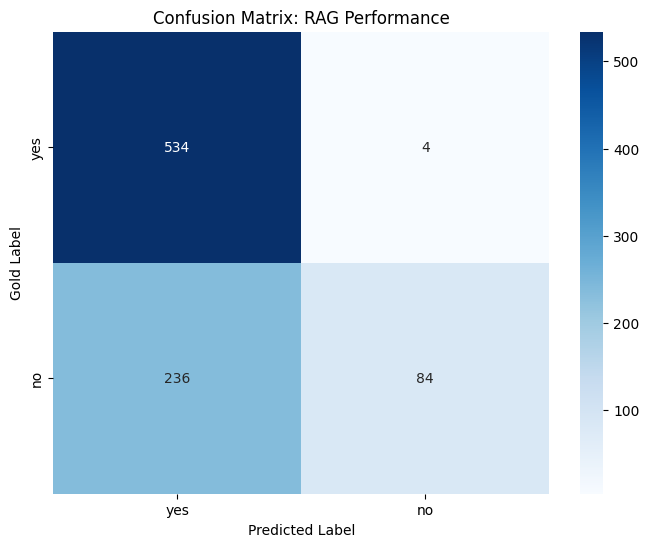

              precision    recall  f1-score   support

         yes       0.95      0.26      0.41       320
          no       0.69      0.99      0.82       538

    accuracy                           0.72       858
   macro avg       0.82      0.63      0.61       858
weighted avg       0.79      0.72      0.67       858



In [ ]:
evaluate(questions, pred_answers, used_contexts)

## Run it without retrieval context

[transformers] Both `max_new_tokens` (=2) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Chain Output:
Yes.


Processing questions:   0%|                                                          | 0/890 [00:00<?, ?it/s][transformers] Both `max_new_tokens` (=2) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=2) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Processing questions:   0%|                                                  | 2/890 [00:00<01:03, 13.92it/s][transformers] Both `max_new_tokens` (=2) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

Context Recall: 0.00%
Vaild yes/no: 66.97%


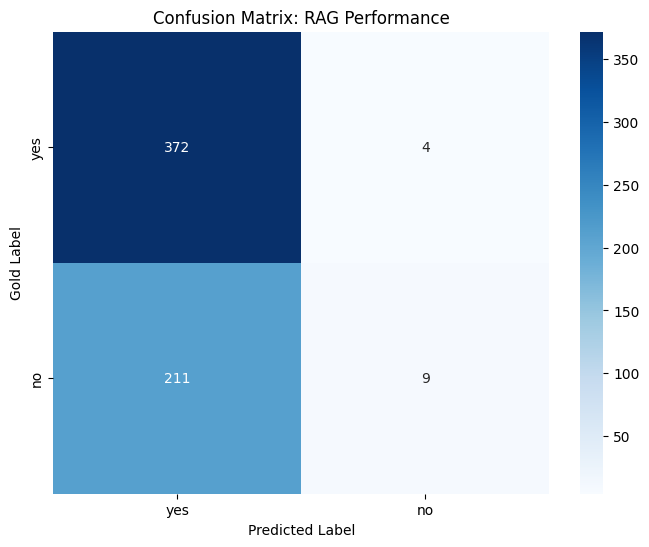

              precision    recall  f1-score   support

         yes       0.69      0.04      0.08       220
          no       0.64      0.99      0.78       376

    accuracy                           0.64       596
   macro avg       0.67      0.52      0.43       596
weighted avg       0.66      0.64      0.52       596



In [ ]:
evaluate(questions, pred_answers, used_contexts)